# MET-type reference transcriptomes

Builds per-MET-type median CPM reference transcriptomes from the Allen Patch-seq dataset,
restricted to L1–4 inhibitory neurons in primary visual cortex.

In [1]:
import sys
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────────
PSEQ_ROOT = Path('/mnt/anastasia/data/ali/allen-pseq')
MERGED    = PSEQ_ROOT / 'merged'
CONDENSED = PSEQ_ROOT / 'condensed'

# pyarrow 10.0.0 can read the parquet; pandas needs 10.0.1+ so we bypass
# the version check by calling pyarrow directly
def read_parquet(path):
    return pq.read_table(path).to_pandas()

print('Paths OK:', MERGED.exists())

Paths OK: True


In [2]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom modules
import data_loader
import cell_filter
import diff_expression
import marker_selection
import visualization

# Configure plotting
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(8, 6))
sns.set_style('whitegrid')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. Load data

In [3]:
# Use transcriptomics_all_cells.parquet (4,435 cells) rather than
# merged/transcriptomics.parquet (2,434 cells). The merged file is limited
# to cells with successful ephys extraction; ~200 MET-typed cells failed
# ephys but have valid RNA and are only present in the condensed file.
tx = read_parquet(CONDENSED / 'transcriptomics_all_cells.parquet')
print(f'Transcriptomics: {tx.shape[0]} cells × {tx.shape[1]} columns')
print('Key columns:', tx.columns[:4].tolist())

Transcriptomics: 4435 cells × 45771 columns
Key columns: ['ephys_session_id', 'transcriptomics_sample_id', 'cell_specimen_id', '0610005C13Rik']


In [4]:
# Manifest: cell-type labels, structure, donor info
manifest = pd.read_csv(
    PSEQ_ROOT / '68d61b068b5cfcfd77c92050_20200711_patchseq_metadata_mouse.csv',
    low_memory=False,
)
print(f'Manifest: {manifest.shape[0]} cells')
print('MET types with ≥1 cell:', manifest['MET-type Label'].notna().sum())

Manifest: 4435 cells
MET types with ≥1 cell: 495


In [5]:
# Join: cell_specimen_id is int in tx, str in manifest
label_cols = ['cell_specimen_id', 'MET-type Label', 'T-type Label', 'structure', 'dendrite_type']
labels = manifest[label_cols].copy()
labels['cell_specimen_id'] = labels['cell_specimen_id'].astype(str)

tx_labeled = tx.assign(
    cell_specimen_id=tx['cell_specimen_id'].astype(str)
).merge(labels, on='cell_specimen_id', how='left')

print(f'After join: {tx_labeled.shape[0]} cells')
print(f'Cells with MET-type label: {tx_labeled["MET-type Label"].notna().sum()}')

After join: 4435 cells
Cells with MET-type label: 495


## 2. Filter to L1–4 inhibitory neurons

In [6]:
L1_4_PATTERNS = ('1', '2/3', '4')
MIN_CELLS_PER_MET = 4  # set to None to skip this filter

def is_l1_4(structure_val):
    if not isinstance(structure_val, str):
        return False
    return any(structure_val.endswith(p) for p in L1_4_PATTERNS)

mask_layer = tx_labeled['structure'].apply(is_l1_4)
mask_met   = tx_labeled['MET-type Label'].notna()

tx_l14 = tx_labeled[mask_layer & mask_met].copy()
print(f'L1–4 cells with MET label: {len(tx_l14)}')

# Optionally drop MET types with too few L1–4 cells — these are likely types
# whose home layer is elsewhere and whose few L1–4 cells are stragglers.
if MIN_CELLS_PER_MET is not None:
    met_counts_all = tx_l14['MET-type Label'].value_counts()
    kept_types  = met_counts_all[met_counts_all >= MIN_CELLS_PER_MET].index
    dropped     = met_counts_all[met_counts_all <  MIN_CELLS_PER_MET]
    tx_l14 = tx_l14[tx_l14['MET-type Label'].isin(kept_types)].copy()
    print(f'Dropped {len(dropped)} MET type(s) with <{MIN_CELLS_PER_MET} cells: '
          f'{dropped.index.tolist()}')
    print(f'Remaining: {len(tx_l14)} cells across {tx_l14["MET-type Label"].nunique()} MET types')

print()

# Sort by cardinal class order, then by MET number within each class
SUBCLASS_ORDER = ['Pvalb', 'Sst', 'Vip', 'Lamp5', 'Sncg']

counts = tx_l14['MET-type Label'].value_counts().reset_index()
counts.columns = ['MET-type Label', 'n_cells']
counts['subclass'] = counts['MET-type Label'].str.split('-').str[0]
counts['met_num']  = counts['MET-type Label'].str.extract(r'MET-(\d+)').astype(int)
counts['subclass_order'] = counts['subclass'].map({s: i for i, s in enumerate(SUBCLASS_ORDER)})
counts = counts.sort_values(['subclass_order', 'met_num']).drop(columns=['subclass_order', 'met_num'])
counts = counts.set_index('MET-type Label')

print('Cells per MET type:')
print(counts)

L1–4 cells with MET label: 231
Dropped 5 MET type(s) with <4 cells: ['Sncg-MET-2', 'Sst-MET-12', 'Sst-MET-4', 'Vip-MET-3', 'Sst-MET-7']
Remaining: 223 cells across 12 MET types

Cells per MET type:
                n_cells subclass
MET-type Label                  
Pvalb-MET-4          29    Pvalb
Pvalb-MET-5           4    Pvalb
Sst-MET-1             5      Sst
Sst-MET-2            16      Sst
Sst-MET-3            26      Sst
Sst-MET-8             8      Sst
Vip-MET-1            22      Vip
Vip-MET-2            15      Vip
Vip-MET-4            16      Vip
Vip-MET-5            21      Vip
Lamp5-MET-1          38    Lamp5
Sncg-MET-1           23     Sncg


In [7]:
# Structure breakdown
print('Structure × MET-type counts:')
ct = tx_l14.groupby(['structure', 'MET-type Label']).size().unstack(fill_value=0)
print(ct.to_string())

Structure × MET-type counts:
MET-type Label  Lamp5-MET-1  Pvalb-MET-4  Pvalb-MET-5  Sncg-MET-1  Sst-MET-1  Sst-MET-2  Sst-MET-3  Sst-MET-8  Vip-MET-1  Vip-MET-2  Vip-MET-4  Vip-MET-5
structure                                                                                                                                                
VISal2/3                  0            0            0           0          0          0          0          0          0          1          0          0
VISal4                    0            0            0           0          0          0          0          0          0          0          2          0
VISam2/3                  0            0            1           0          0          0          0          0          0          0          0          0
VISam4                    0            1            0           0          0          0          0          0          0          0          0          0
VISl1                     0            0       

## 3. Reference transcriptomes — median CPM per MET type

In [8]:
# Gene columns = everything after the bookkeeping / metadata columns
meta_cols = [
    'ephys_session_id', 'transcriptomics_sample_id', 'cell_specimen_id',
    'MET-type Label', 'T-type Label', 'structure', 'dendrite_type',
]
gene_cols = [c for c in tx_l14.columns if c not in meta_cols]
print(f'{len(gene_cols)} gene columns')

# Median CPM per MET type  →  shape: (n_MET_types × n_genes)
met_ref = (
    tx_l14
    .groupby('MET-type Label')[gene_cols]
    .median()
)
print(f'Reference shape: {met_ref.shape}  (MET types × genes)')
print('MET types:')
for met in met_ref.index:
    n = (tx_l14['MET-type Label'] == met).sum()
    print(f'  {met}: {n} cells')

45768 gene columns
Reference shape: (12, 45768)  (MET types × genes)
MET types:
  Lamp5-MET-1: 38 cells
  Pvalb-MET-4: 29 cells
  Pvalb-MET-5: 4 cells
  Sncg-MET-1: 23 cells
  Sst-MET-1: 5 cells
  Sst-MET-2: 16 cells
  Sst-MET-3: 26 cells
  Sst-MET-8: 8 cells
  Vip-MET-1: 22 cells
  Vip-MET-2: 15 cells
  Vip-MET-4: 16 cells
  Vip-MET-5: 21 cells


In [9]:
# Cell counts per MET type (useful metadata to keep alongside the reference)
met_cell_counts = tx_l14['MET-type Label'].value_counts()
print(met_cell_counts)

MET-type Label
Lamp5-MET-1    38
Pvalb-MET-4    29
Sst-MET-3      26
Sncg-MET-1     23
Vip-MET-1      22
Vip-MET-5      21
Vip-MET-4      16
Sst-MET-2      16
Vip-MET-2      15
Sst-MET-8       8
Sst-MET-1       5
Pvalb-MET-5     4
Name: count, dtype: int64


## 4. Quick sanity checks

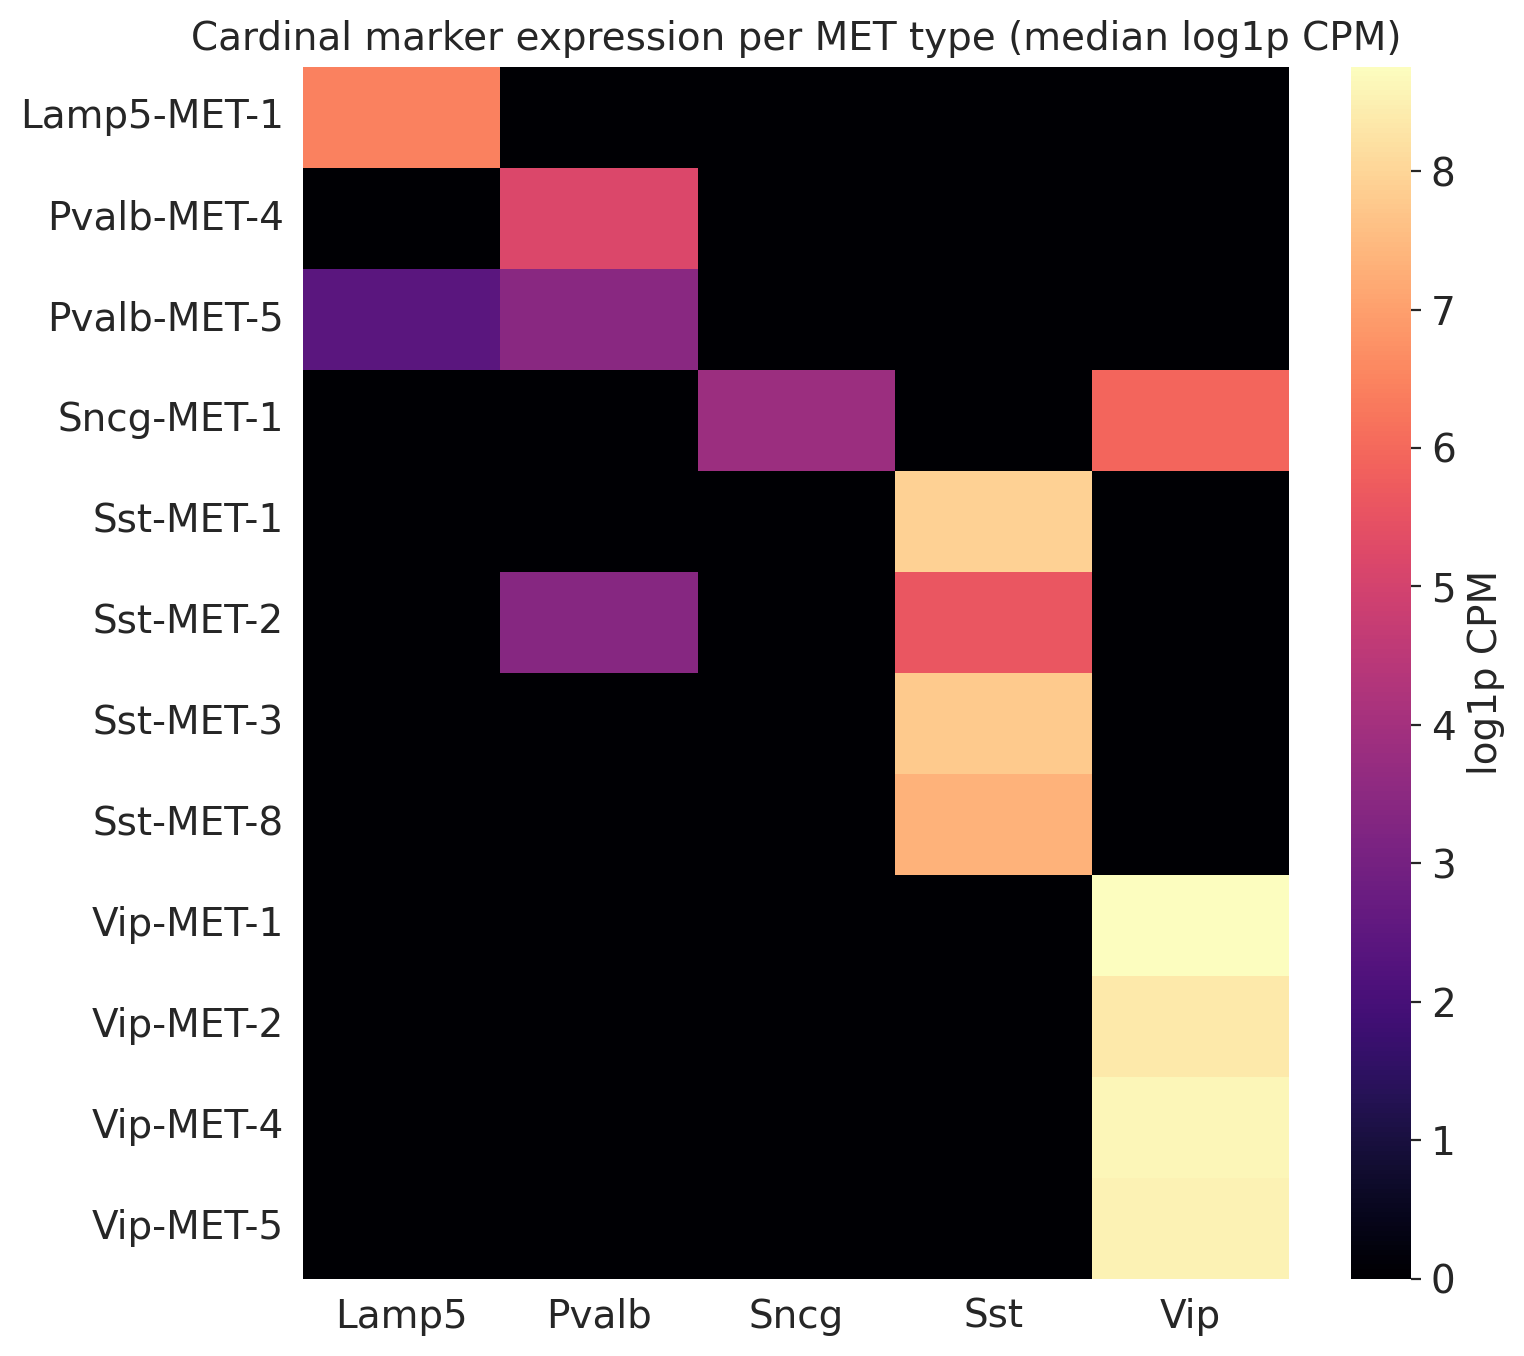

In [10]:
# Subclass marker genes — should show expected enrichment
CARDINAL_MARKERS = ['Lamp5','Pvalb','Sncg','Sst','Vip']
available_markers = [g for g in CARDINAL_MARKERS if g in met_ref.columns]

marker_ref = met_ref[available_markers]

fig, ax = plt.subplots(figsize=(8, 0.5 * len(met_ref) + 1))
sns.heatmap(
    np.log1p(marker_ref),
    ax=ax,
    cmap='magma',
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'log1p CPM'},
)
ax.set_title('Cardinal marker expression per MET type (median log1p CPM)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show() 



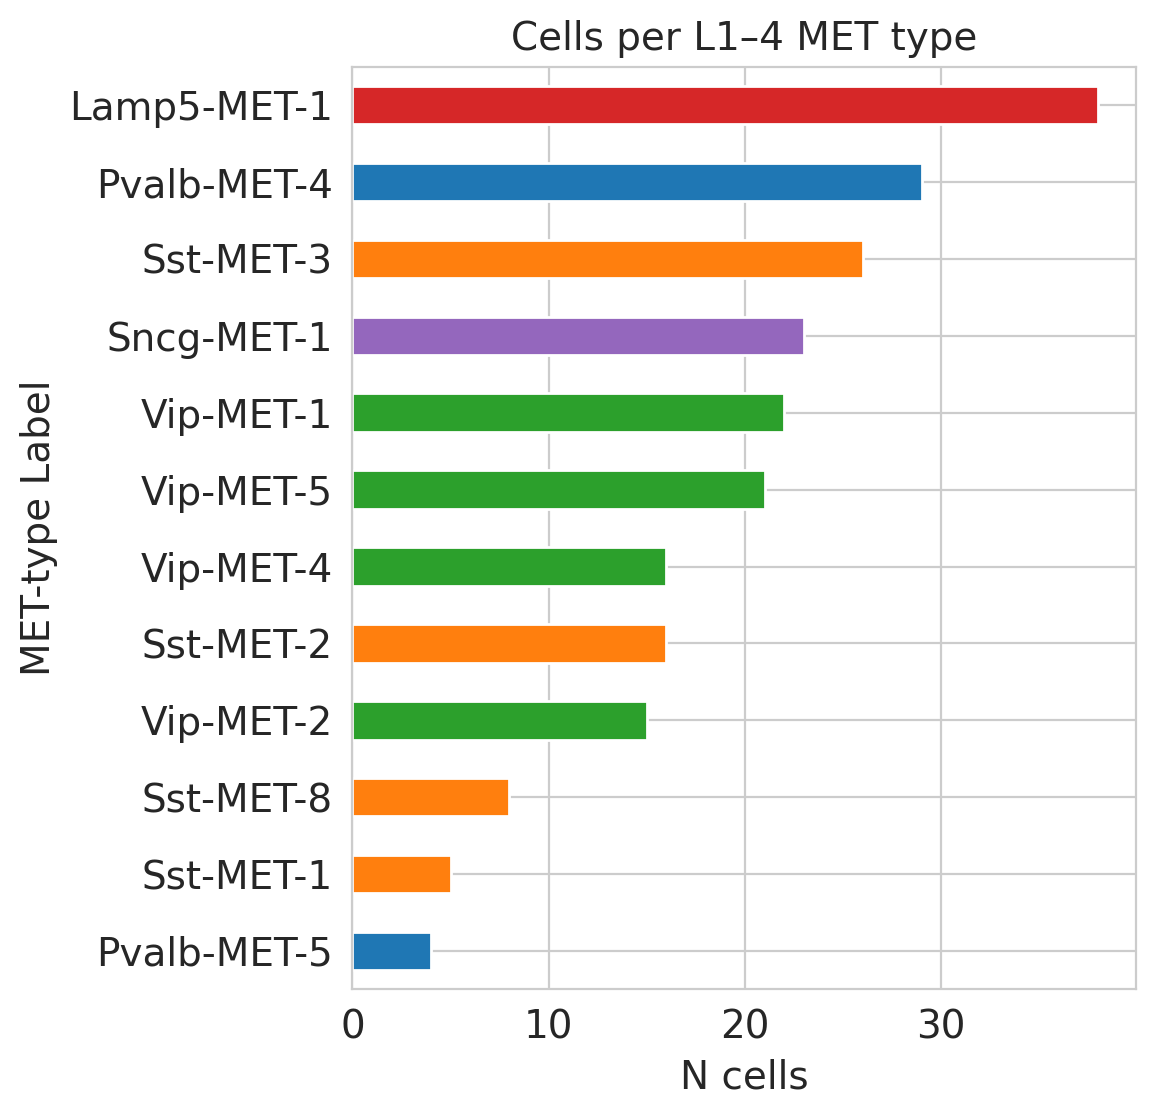

In [11]:
# Cell count bar plot
fig, ax = plt.subplots(figsize=(6, 0.4 * len(met_cell_counts) + 1))
colors = []
subclass_palette = {
    'Pvalb': '#1f77b4', 'Sst': '#ff7f0e', 'Vip': '#2ca02c',
    'Lamp5': '#d62728', 'Sncg': '#9467bd',
}
for met in met_cell_counts.index:
    sc = met.split('-')[0]
    colors.append(subclass_palette.get(sc, '#7f7f7f'))

met_cell_counts.plot.barh(ax=ax, color=colors)
ax.set_xlabel('N cells')
ax.set_title('Cells per L1–4 MET type')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Save reference

`met_ref` — DataFrame indexed by MET-type label, columns = gene symbols, values = median CPM.  
Use this in downstream mapping notebooks.

In [12]:
print('met_ref summary')
print(f'  Shape : {met_ref.shape}')
print(f'  Index : {met_ref.index.tolist()}')
print(f'  Values: median CPM, range [{met_ref.values.min():.1f}, {met_ref.values.max():.1f}]')
print()
print('Variables available for downstream use:')
print('  met_ref          — MET-type × gene median CPM reference')
print('  met_cell_counts  — N cells per MET type')
print('  tx_l14           — per-cell CPM + metadata for L1–4 MET-typed cells')
print('  gene_cols        — list of gene symbol column names')

met_ref summary
  Shape : (12, 45768)
  Index : ['Lamp5-MET-1', 'Pvalb-MET-4', 'Pvalb-MET-5', 'Sncg-MET-1', 'Sst-MET-1', 'Sst-MET-2', 'Sst-MET-3', 'Sst-MET-8', 'Vip-MET-1', 'Vip-MET-2', 'Vip-MET-4', 'Vip-MET-5']
  Values: median CPM, range [0.0, 48372.2]

Variables available for downstream use:
  met_ref          — MET-type × gene median CPM reference
  met_cell_counts  — N cells per MET type
  tx_l14           — per-cell CPM + metadata for L1–4 MET-typed cells
  gene_cols        — list of gene symbol column names


## Map tasic data to the MET types

In [13]:
# Paths to Allen Brain Map VISp SMART-seq data
DATA_DIR = '/mnt/nasquatch/data/RNAseq/allenV1_SMART-seq'

expression_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_exon-matrix.csv'
metadata_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_samples-columns.csv'
genes_path = f'{DATA_DIR}/mouse_VISp_2018-06-14_genes-rows.csv'

# Cache filtered results to disk — re-runs load in seconds instead of minutes
cell_filter.set_cache_dir(f'{DATA_DIR}/cache')

# Superficial-layer GABAergic cells: all brain_subregion values spanning L1–L4.
# The UMAP cache (umap_gaba.csv) was computed on all GABAergic cells, so the
# coordinates for this subset are already present and will be sliced correctly.
SUPERFICIAL_LAYERS = ['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4']

adata_l23_inh = data_loader.load_allen_filtered(
    metadata_path=metadata_path,
    expression_path=expression_path,
    target_class='GABAergic',
    target_layers=SUPERFICIAL_LAYERS,
    genes_path=genes_path,
    layer_name='counts',
    obsm_paths={'X_umap': f'{DATA_DIR}/cache/umap_gaba.csv'},
)
adata_l23_inh

if 'X_umap' not in adata_l23_inh.obsm:
    sc.pp.normalize_total(adata_l23_inh)
    sc.pp.log1p(adata_l23_inh)
    sc.pp.pca(adata_l23_inh)
    sc.pp.neighbors(adata_l23_inh)
    sc.tl.umap(adata_l23_inh)

    pd.DataFrame(
        adata_l23_inh.obsm['X_umap'],
        index=adata_l23_inh.obs_names,
        columns=['umap_1', 'umap_2'],
    ).to_csv(f'{DATA_DIR}/cache/umap_gaba.csv') 
    

Loading metadata from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_samples-columns.csv...
Loaded metadata: 15413 cells × 49 columns
Key columns: ['class', 'subclass', 'cluster']
Metadata filter: 3215 of 15413 cells selected (class='GABAergic', layers=['L1', 'L1-L2/3', 'L1-L4', 'L1-L6', 'L2/3', 'L2/3-L4', 'L4'])
Loading expression matrix from /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/mouse_VISp_2018-06-14_exon-matrix.csv...
  Reading 3215 of 15413 cell columns...
Loaded expression: 3215 cells × 45768 genes
Creating AnnData with 3215 cells

Cell classes: 1
class
GABAergic    3215
Name: count, dtype: int64
Loading obsm embeddings...
  obsm['X_umap']: loaded shape (3215, 2)


In [14]:
# Remove subclasses with no MET-type representation in the patch-seq reference
EXCLUDE_SUBCLASSES = {'Serpinf1', 'Meis2'}
keep = ~adata_l23_inh.obs['subclass'].isin(EXCLUDE_SUBCLASSES)
adata_l23_inh = adata_l23_inh[keep].copy()
print(f'Retained {adata_l23_inh.n_obs} cells after removing {EXCLUDE_SUBCLASSES}')

Retained 3202 cells after removing {'Meis2', 'Serpinf1'}


In [30]:
## Two-step MET-type assignment
#
# Step 1: use the Allen-annotated subclass label from adata_l23_inh.obs['subclass']
#         as the cardinal class — no re-derivation needed, these are curated.
# Step 2: within each cardinal class, pick the nearest MET centroid by cosine
#         similarity on log1p(CPM) over the shared gene set.
#
# Normalization: Tasic raw counts → per-cell CPM (full-genome total) → log1p.
#               MET ref is already CPM → log1p.

from sklearn.metrics.pairwise import cosine_similarity as cos_sim

SUBCLASS_ORDER_MET = ['Pvalb', 'Sst', 'Vip', 'Lamp5', 'Sncg']

# ── 1. Shared gene set ─────────────────────────────────────────────────────────
sym_to_entrez = pd.Series(
    adata_l23_inh.var_names,
    index=adata_l23_inh.var['gene_symbol'],
)
sym_to_entrez = sym_to_entrez[~sym_to_entrez.index.duplicated(keep='first')]

shared_genes   = sorted(set(met_ref.columns) & set(sym_to_entrez.index))
shared_entrez  = sym_to_entrez[shared_genes].values
shared_col_idx = [adata_l23_inh.var_names.get_loc(e) for e in shared_entrez]
print(f'Shared genes: {len(shared_genes):,}  '
      f'(met_ref: {len(met_ref.columns):,} / Tasic: {len(sym_to_entrez):,})')

# ── 2. Tasic log1p(CPM) on shared genes ───────────────────────────────────────
cell_total = adata_l23_inh.layers['counts'].sum(axis=1, keepdims=True)
X_raw      = adata_l23_inh.layers['counts'][:, shared_col_idx]
X_log      = np.log1p(X_raw / cell_total * 1e6)

# ── 3. MET reference log1p(CPM) ───────────────────────────────────────────────
ref_log   = np.log1p(met_ref[shared_genes].values)
met_names = list(met_ref.index)
met_idx   = {m: i for i, m in enumerate(met_names)}

# ── 4. Step 1 — cardinal class from Allen annotation ──────────────────────────
cardinal_class = adata_l23_inh.obs['subclass'].values.astype(str)

print('Cardinal class distribution:')
print(pd.Series(cardinal_class).value_counts().rename('n_cells').to_string())

# ── 5. Step 2 — within-class cosine similarity → MET type ─────────────────────
subclass_to_mets = {
    sc: [m for m in met_ref.index if m.startswith(sc + '-')]
    for sc in SUBCLASS_ORDER_MET
}

n_cells      = adata_l23_inh.n_obs
met_assigned = np.full(n_cells, 'Unknown', dtype=object)

for sc, mets in subclass_to_mets.items():
    if not mets:
        continue
    mask = cardinal_class == sc
    if not mask.any():
        continue
    ref_sc = ref_log[[met_idx[m] for m in mets]]   # (n_mets_in_class, n_shared)
    sim    = cos_sim(X_log[mask], ref_sc)            # (n_cells_in_class, n_mets)
    met_assigned[mask] = [mets[i] for i in sim.argmax(axis=1)]

# Cells whose subclass has no MET type in the reference (e.g. Serpinf1, Meis2)
unassigned = met_assigned == 'Unknown'
if unassigned.any():
    print(f'\n{unassigned.sum()} cells have no matching MET subclass '
          f'(subclasses: {pd.Series(cardinal_class[unassigned]).value_counts().to_dict()})')

adata_l23_inh.obs['met_type_pred'] = met_assigned

print('\nMET-type assignment (two-step):')
pred_counts = pd.Series(met_assigned).value_counts().reset_index()
pred_counts.columns = ['MET-type', 'n_cells']
pred_counts['subclass'] = pred_counts['MET-type'].str.split('-').str[0]
pred_counts['met_num']  = pred_counts['MET-type'].str.extract(r'MET-(\d+)').fillna(0).astype(int)
pred_counts['sc_order'] = pred_counts['subclass'].map(
    {s: i for i, s in enumerate(SUBCLASS_ORDER_MET)}
)
pred_counts = pred_counts.sort_values(['sc_order', 'met_num']).drop(
    columns=['sc_order', 'met_num']
)
print(pred_counts.to_string(index=False))

Shared genes: 45,768  (met_ref: 45,768 / Tasic: 45,768)
Cardinal class distribution:
Vip      1327
Lamp5     981
Pvalb     513
Sst       315
Sncg       66

MET-type assignment (two-step):
   MET-type  n_cells subclass
Pvalb-MET-4      513    Pvalb
  Sst-MET-2      157      Sst
  Sst-MET-3      158      Sst
  Vip-MET-1       95      Vip
  Vip-MET-2        1      Vip
  Vip-MET-4     1226      Vip
  Vip-MET-5        5      Vip
Lamp5-MET-1      981    Lamp5
 Sncg-MET-1       66     Sncg


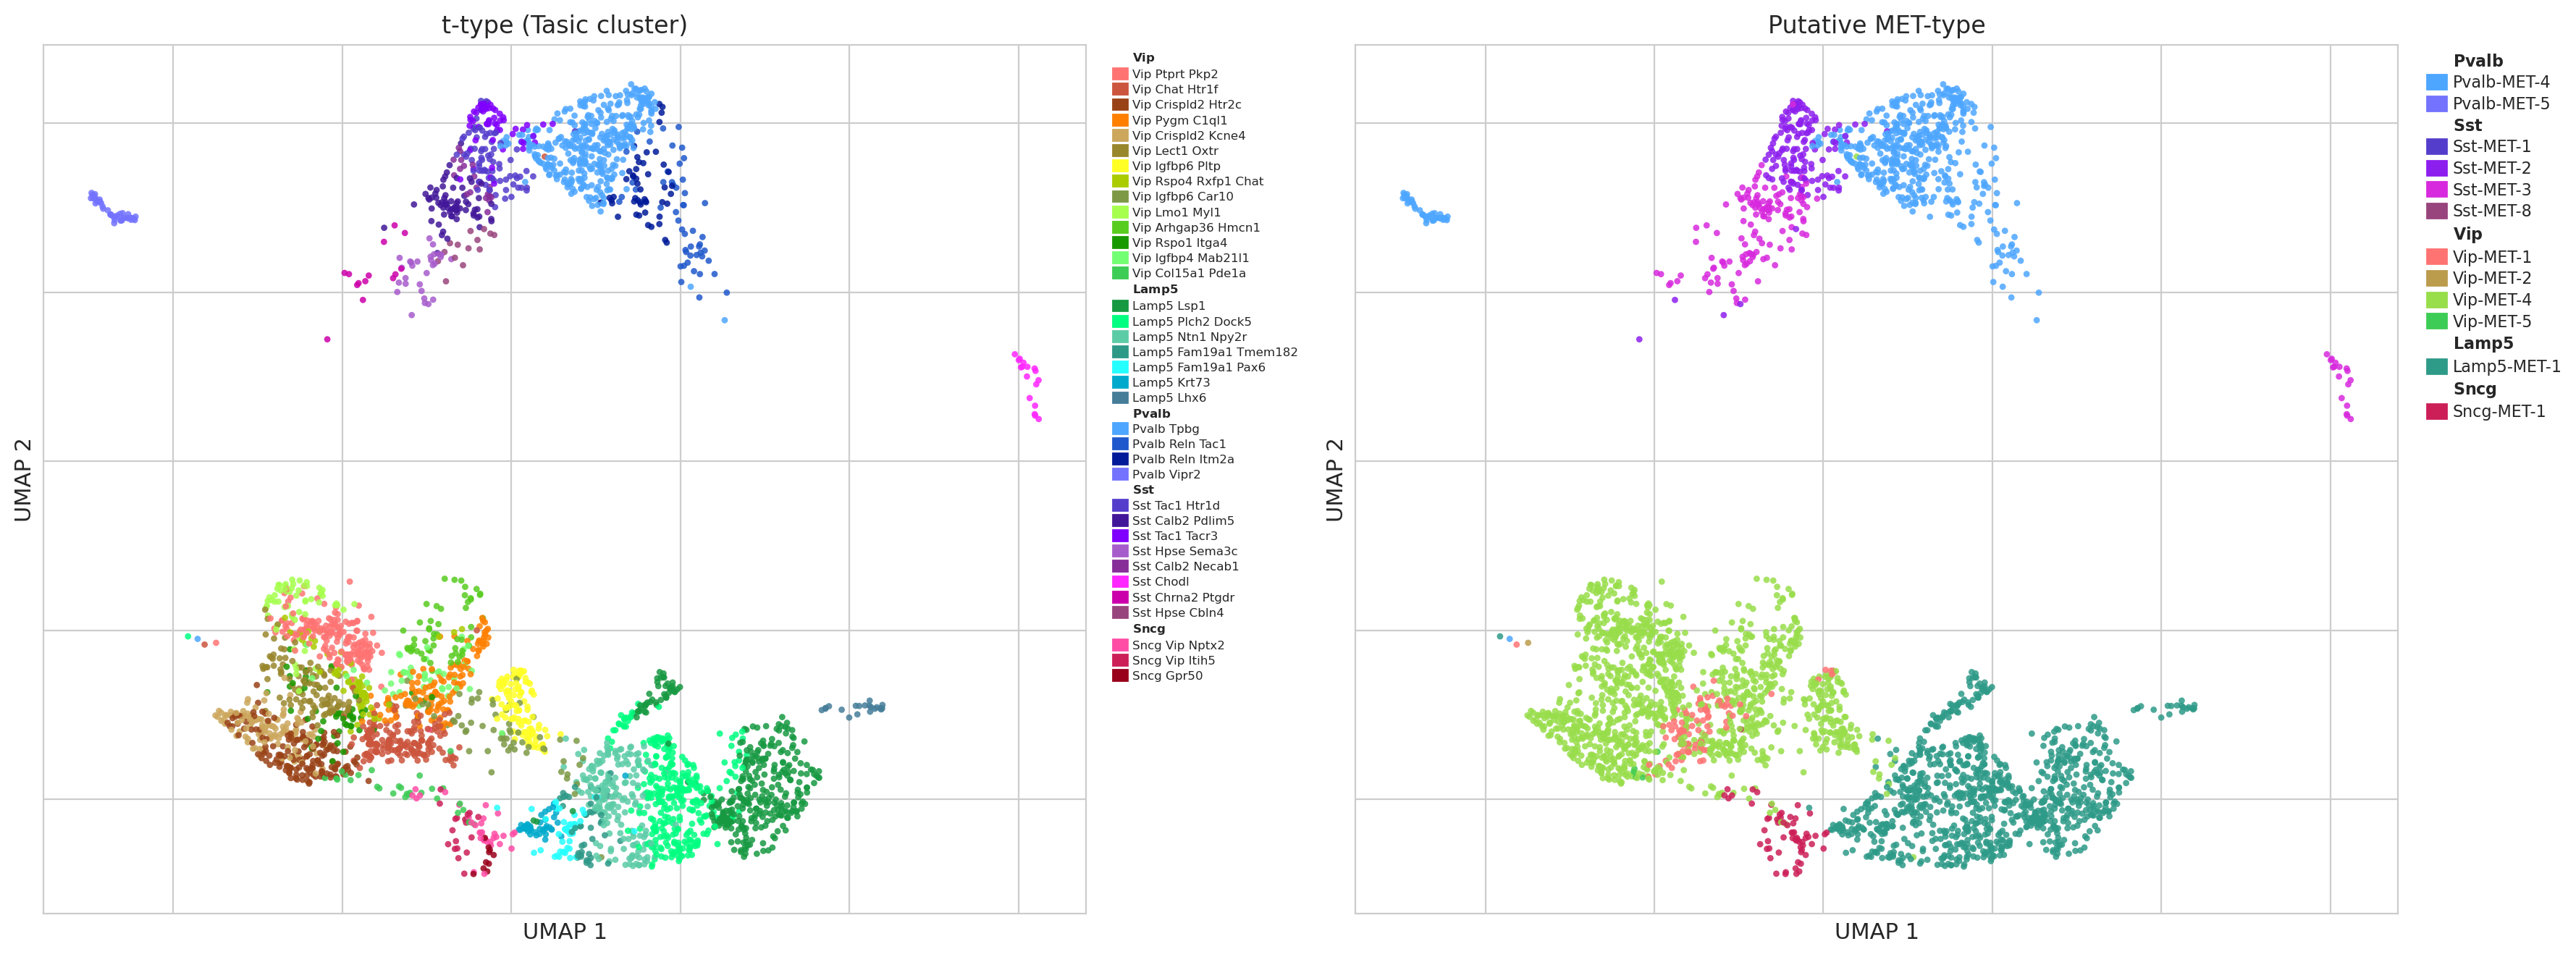

In [31]:
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
# from visualization import varibow

obs = adata_l23_inh.obs[['subclass', 'cluster', 'met_type_pred']].copy()

# Drop clusters with <10 cells
cluster_counts = obs['cluster'].value_counts()
valid_clusters  = cluster_counts[cluster_counts >= 10].index
obs = obs[obs['cluster'].isin(valid_clusters)]

cell_positions = adata_l23_inh.obs_names.get_indexer(obs.index)
umap = adata_l23_inh.obsm['X_umap'][cell_positions]

# ── Left panel: t-type (cluster) colors ───────────────────────────────────────
subclass_order      = obs['subclass'].value_counts().index.tolist()
cluster_to_subclass = obs.groupby('cluster')['subclass'].first()
cluster_order = []
for sc in subclass_order:
    cluster_order.extend(obs.loc[obs['subclass'] == sc, 'cluster'].value_counts().index.tolist())

palette_cl    = varibow(len(cluster_order))
cluster_color = {c: palette_cl[i] for i, c in enumerate(cluster_order)}
colors_left   = np.array([cluster_color[c] for c in obs['cluster']])

# ── Right panel: MET-type colors sampled from the same subclass color bands ───
# For each subclass, identify which slice of palette_cl it occupies,
# then interpolate that color range to assign one color per MET type.
sc_palette_range = {}
i = 0
for sc in subclass_order:
    n = sum(1 for c in cluster_order if cluster_to_subclass[c] == sc)
    sc_palette_range[sc] = np.array(palette_cl[i:i + n])
    i += n

met_order = []
met_color  = {}
for sc in SUBCLASS_ORDER_MET:
    mets = sorted(
        [m for m in met_ref.index if m.startswith(sc + '-')],
        key=lambda x: int(x.split('-MET-')[1]),
    )
    met_order.extend(mets)
    if not mets or sc not in sc_palette_range or len(sc_palette_range[sc]) == 0:
        for m in mets:
            met_color[m] = np.array([0.5, 0.5, 0.5])
        continue

    sc_colors = sc_palette_range[sc]
    cmap = LinearSegmentedColormap.from_list('', sc_colors)
    positions = [0.5] if len(mets) == 1 else np.linspace(0, 1, len(mets))
    for m, pos in zip(mets, positions):
        met_color[m] = np.array(cmap(pos)[:3])

colors_right = np.array([met_color[m] for m in obs['met_type_pred']])

# ── Figure ─────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(umap))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
scatter_kw = dict(s=10, linewidths=0, alpha=0.85, rasterized=True)

for ax, colors, title in zip(
    axes,
    [colors_left, colors_right],
    ['t-type (Tasic cluster)', 'Putative MET-type'],
):
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors[idx], **scatter_kw)
    ax.set_xlabel('UMAP 1', fontsize=11)
    ax.set_ylabel('UMAP 2', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Left legend: clusters grouped by subclass
handles_left = []
for sc in subclass_order:
    handles_left.append(mpatches.Patch(facecolor='none', edgecolor='none', label=f'$\\bf{{{sc}}}$'))
    for c in [c for c in cluster_order if cluster_to_subclass[c] == sc]:
        handles_left.append(mpatches.Patch(color=cluster_color[c], label=c))
axes[0].legend(handles=handles_left, bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=6, frameon=False, handlelength=1.2, handleheight=1.0,
               borderpad=0, labelspacing=0.3)

# Right legend: MET types grouped by subclass, same color band as left
handles_right = []
for sc in SUBCLASS_ORDER_MET:
    mets = [m for m in met_order if m.startswith(sc + '-')]
    if not mets:
        continue
    handles_right.append(mpatches.Patch(facecolor='none', edgecolor='none', label=f'$\\bf{{{sc}}}$'))
    for m in mets:
        handles_right.append(mpatches.Patch(color=met_color[m], label=m))
axes[1].legend(handles=handles_right, bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8, frameon=False, handlelength=1.2, handleheight=1.0,
               borderpad=0, labelspacing=0.3)

plt.tight_layout()
plt.show()

In [32]:
## MET-type composition: which T-type cardinal classes and clusters map to each MET type?

df = adata_l23_inh.obs[['subclass', 'cluster', 'met_type_pred']].copy()

for met in met_order:
    subset = df[df['met_type_pred'] == met]
    if subset.empty:
        continue

    print(f'━━━  {met}  ({len(subset)} cells)  ━━━')

    # 1) Cardinal class breakdown
    sc_counts = subset['subclass'].value_counts()
    sc_counts = sc_counts.reindex(
        [s for s in SUBCLASS_ORDER_MET if s in sc_counts.index]
    ).dropna().astype(int)
    print('  Cardinal classes:')
    for sc, n in sc_counts.items():
        print(f'    {sc:<12s} {n:>4d}  ({100*n/len(subset):.0f}%)')

    # 2) Cluster breakdown, sorted by cardinal class then by count within class
    cl_counts = subset.groupby(['subclass', 'cluster']).size().reset_index(name='n')
    cl_counts['sc_order'] = cl_counts['subclass'].map(
        {s: i for i, s in enumerate(SUBCLASS_ORDER_MET)}
    )
    cl_counts = cl_counts.sort_values(['sc_order', 'n'], ascending=[True, False])
    print('  T-type clusters:')
    for _, row in cl_counts.iterrows():
        print(f'    [{row["subclass"]:<8s}]  {row["cluster"]:<35s} {row["n"]:>4d}')

    print()

━━━  Pvalb-MET-4  (513 cells)  ━━━
  Cardinal classes:
    Pvalb         513  (100%)
  T-type clusters:
    [Pvalb   ]  Pvalb Tpbg                           367
    [Pvalb   ]  Pvalb Reln Tac1                       50
    [Pvalb   ]  Pvalb Reln Itm2a                      49
    [Pvalb   ]  Pvalb Vipr2                           42
    [Pvalb   ]  Pvalb Gpr149 Islr                      3
    [Pvalb   ]  Pvalb Calb1 Sst                        2

━━━  Sst-MET-2  (157 cells)  ━━━
  Cardinal classes:
    Sst           157  (100%)
  T-type clusters:
    [Sst     ]  Sst Tac1 Htr1d                        76
    [Sst     ]  Sst Tac1 Tacr3                        52
    [Sst     ]  Sst Calb2 Necab1                      10
    [Sst     ]  Sst Calb2 Pdlim5                       5
    [Sst     ]  Sst Mme Fam114a1                       4
    [Sst     ]  Sst Chrna2 Glra3                       2
    [Sst     ]  Sst Chrna2 Ptgdr                       2
    [Sst     ]  Sst Hpse Sema3c                     

In [33]:
## Two-step MET assignment using within-class marker genes only

MARKER_GENES_PER_CLASS = {
    'Sst':   ['Chodl','Tac1','Calb2','Pdlim5','Necab1','Nr2f2','Chrna2','Sema3c','Hpse','Ndnf','Crh','Rxfp1','Esm1','Nts'],
    'Pvalb': ['Gabrg1','Bche','Th','Sst','Sema3e','Htr2c','Reln','Calb1','Pdlim3','Vipr2'],
    'Lamp5': ['Npy','Ndnf','Necab1','Sema3e','Nr2f2','Lhx6'],
    'Sncg':  ['Cck','Reln','Vip','Nptx2','Car10','Krt73','Slc17a8'],
    'Vip':   ['Cck','Npy','Chat','Ptprt','Rspo1','Sfrp2','Lmo1','Myl1','Crispld2'],
}

# Sparse clusters hardcoded to a specific MET type.
# These MET types are EXCLUDED from cosine similarity for all other cells (1:1 rule).
CLUSTER_OVERRIDES = {
    'Sst Chodl':   'Sst-MET-1',
    'Pvalb Vipr2': 'Pvalb-MET-5',
}
reserved_mets = set(CLUSTER_OVERRIDES.values())

shared_gene_pos = {g: i for i, g in enumerate(shared_genes)}

n_cells         = adata_l23_inh.n_obs
cardinal_class  = adata_l23_inh.obs['subclass'].values.astype(str)
cluster_labels  = adata_l23_inh.obs['cluster'].values.astype(str)
met_assigned_mk = np.full(n_cells, 'Unknown', dtype=object)

print('Marker gene coverage per class:')
for sc, mets in subclass_to_mets.items():
    if not mets:
        continue
    mask = cardinal_class == sc
    if not mask.any():
        continue

    # Remove reserved MET types so they cannot be assigned via cosine similarity
    mets_open = [m for m in mets if m not in reserved_mets]
    if not mets_open:
        continue

    sc_markers  = MARKER_GENES_PER_CLASS.get(sc, [])
    marker_cols = [shared_gene_pos[g] for g in sc_markers if g in shared_gene_pos]
    n_found     = len(marker_cols)
    missing     = [g for g in sc_markers if g not in shared_gene_pos]
    print(f'  {sc:<8s}: {n_found}/{len(sc_markers)} markers found'
          + (f'  (missing: {missing})' if missing else ''))

    if not marker_cols:
        X_sc   = X_log[mask]
        ref_sc = ref_log[[met_idx[m] for m in mets_open]]
    else:
        X_sc   = X_log[mask][:, marker_cols]
        ref_sc = ref_log[[met_idx[m] for m in mets_open]][:, marker_cols]

    sim = cos_sim(X_sc, ref_sc)
    met_assigned_mk[mask] = [mets_open[i] for i in sim.argmax(axis=1)]

# Hardcoded overrides applied last — these are the only path to reserved MET types
print('Applying hardcoded cluster overrides:')
for cluster_name, met_label in CLUSTER_OVERRIDES.items():
    override_mask = cluster_labels == cluster_name
    n = override_mask.sum()
    met_assigned_mk[override_mask] = met_label
    print(f'  {cluster_name!r} ({n} cells) -> {met_label!r}')

adata_l23_inh.obs['met_type_pred_markers'] = met_assigned_mk

print('MET-type assignment (marker genes):')
pred_mk = pd.Series(met_assigned_mk).value_counts().reset_index()
pred_mk.columns = ['MET-type', 'n_cells']
pred_mk['subclass'] = pred_mk['MET-type'].str.split('-').str[0]
pred_mk['met_num']  = pred_mk['MET-type'].str.extract(r'MET-(\d+)').fillna(0).astype(int)
pred_mk['sc_order'] = pred_mk['subclass'].map({s: i for i, s in enumerate(SUBCLASS_ORDER_MET)})
pred_mk = pred_mk.sort_values(['sc_order', 'met_num']).drop(columns=['sc_order', 'met_num'])
print(pred_mk.to_string(index=False))

Marker gene coverage per class:
  Pvalb   : 10/10 markers found
  Sst     : 14/14 markers found
  Vip     : 9/9 markers found
  Lamp5   : 6/6 markers found
  Sncg    : 7/7 markers found
Applying hardcoded cluster overrides:
  'Sst Chodl' (17 cells) -> 'Sst-MET-1'
  'Pvalb Vipr2' (42 cells) -> 'Pvalb-MET-5'
MET-type assignment (marker genes):
   MET-type  n_cells subclass
Pvalb-MET-4      471    Pvalb
Pvalb-MET-5       42    Pvalb
  Sst-MET-1       17      Sst
  Sst-MET-2      160      Sst
  Sst-MET-3       99      Sst
  Sst-MET-8       39      Sst
  Vip-MET-1      412      Vip
  Vip-MET-2      448      Vip
  Vip-MET-4       50      Vip
  Vip-MET-5      417      Vip
Lamp5-MET-1      981    Lamp5
 Sncg-MET-1       66     Sncg


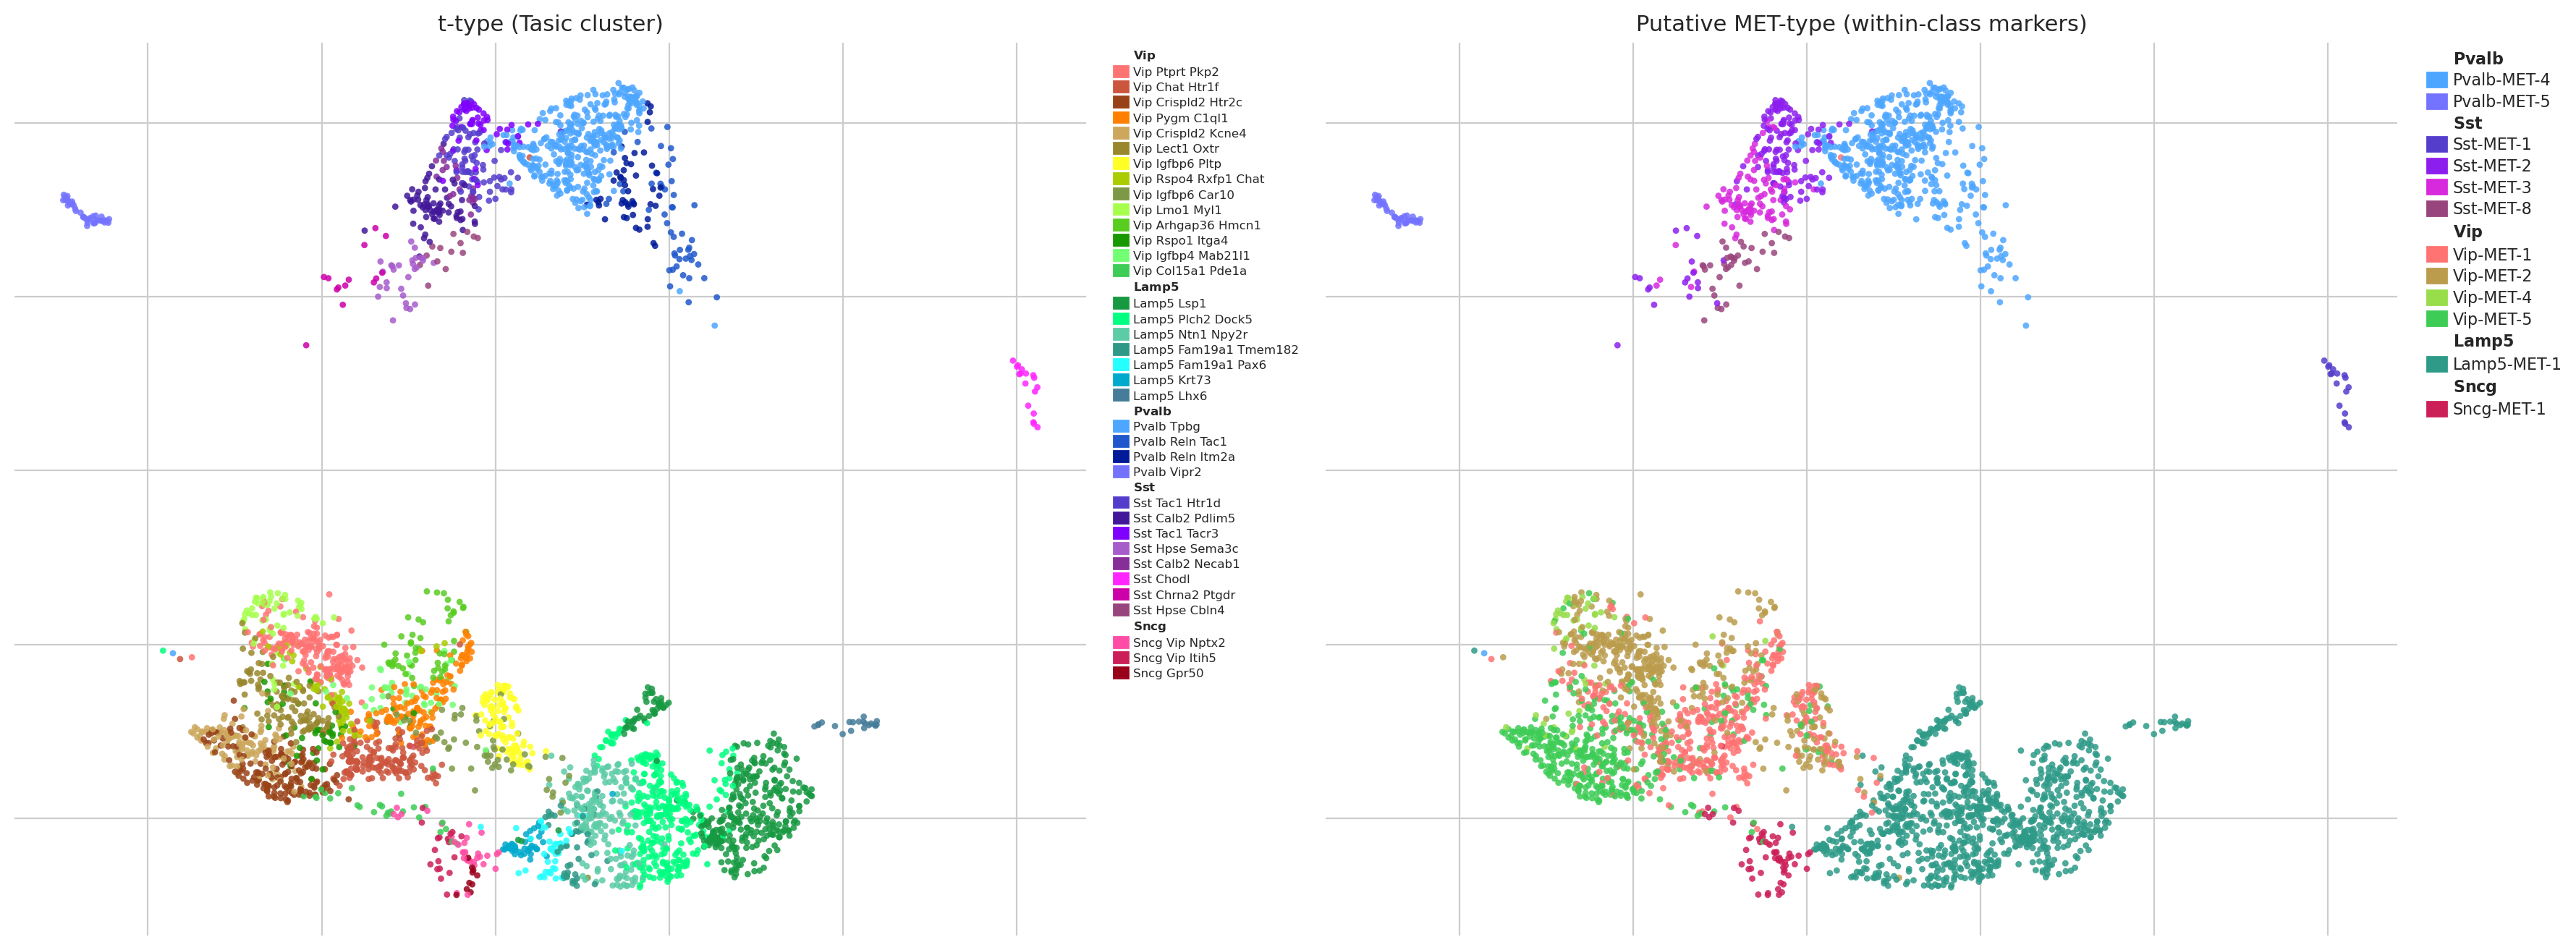

In [34]:
## 2-panel UMAP: t-type | marker-gene MET

import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from visualization import varibow
# from visualization import varibow

obs = adata_l23_inh.obs[['subclass', 'cluster', 'met_type_pred_markers']].copy()

# Drop clusters with <10 cells
cluster_counts = obs['cluster'].value_counts()
valid_clusters  = cluster_counts[cluster_counts >= 10].index
obs = obs[obs['cluster'].isin(valid_clusters)]

cell_positions = adata_l23_inh.obs_names.get_indexer(obs.index)
umap = adata_l23_inh.obsm['X_umap'][cell_positions]

# ── Left panel: t-type cluster colors ─────────────────────────────────────────
subclass_order      = obs['subclass'].value_counts().index.tolist()
cluster_to_subclass = obs.groupby('cluster')['subclass'].first()
cluster_order = []
for sc in subclass_order:
    cluster_order.extend(obs.loc[obs['subclass'] == sc, 'cluster'].value_counts().index.tolist())

palette_cl    = varibow(len(cluster_order))
cluster_color = {c: palette_cl[i] for i, c in enumerate(cluster_order)}
colors_left   = np.array([cluster_color[c] for c in obs['cluster']])

# ── Right panel: MET-type colors from the same subclass color bands ────────────
sc_palette_range = {}
i = 0
for sc in subclass_order:
    n = sum(1 for c in cluster_order if cluster_to_subclass[c] == sc)
    sc_palette_range[sc] = np.array(palette_cl[i:i + n])
    i += n

met_order = []
met_color  = {}
for sc in SUBCLASS_ORDER_MET:
    mets = sorted(
        [m for m in met_ref.index if m.startswith(sc + '-')],
        key=lambda x: int(x.split('-MET-')[1]),
    )
    met_order.extend(mets)
    if not mets or sc not in sc_palette_range or len(sc_palette_range[sc]) == 0:
        for m in mets:
            met_color[m] = np.array([0.5, 0.5, 0.5])
        continue
    sc_colors = sc_palette_range[sc]
    cmap = LinearSegmentedColormap.from_list('', sc_colors)
    positions = [0.5] if len(mets) == 1 else np.linspace(0, 1, len(mets))
    for m, pos in zip(mets, positions):
        met_color[m] = np.array(cmap(pos)[:3])

colors_right = np.array([met_color.get(m, [0.5, 0.5, 0.5]) for m in obs['met_type_pred_markers']])

# ── Figure ─────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
idx = rng.permutation(len(umap))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
scatter_kw = dict(s=10, linewidths=0, alpha=0.85, rasterized=True)

for ax, colors, title in zip(
    axes,
    [colors_left, colors_right],
    ['t-type (Tasic cluster)', 'Putative MET-type (within-class markers)'],
):
    ax.scatter(umap[idx, 0], umap[idx, 1], c=colors[idx], **scatter_kw)
    ax.set_title(title, fontsize=11)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Cluster legend on ax[0]
handles_cl = []
for sc in subclass_order:
    handles_cl.append(mpatches.Patch(facecolor='none', edgecolor='none', label=f'$\\bf{{{sc}}}$'))
    for c in [c for c in cluster_order if cluster_to_subclass[c] == sc]:
        handles_cl.append(mpatches.Patch(color=cluster_color[c], label=c))
axes[0].legend(handles=handles_cl, bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=6, frameon=False, handlelength=1.2, handleheight=1.0,
               borderpad=0, labelspacing=0.3)

# MET-type legend on ax[1]
handles_met = []
for sc in SUBCLASS_ORDER_MET:
    mets = [m for m in met_order if m.startswith(sc + '-')]
    if not mets:
        continue
    handles_met.append(mpatches.Patch(facecolor='none', edgecolor='none', label=f'$\\bf{{{sc}}}$'))
    for m in mets:
        handles_met.append(mpatches.Patch(color=met_color[m], label=m))
axes[1].legend(handles=handles_met, bbox_to_anchor=(1.02, 1), loc='upper left',
               fontsize=8, frameon=False, handlelength=1.2, handleheight=1.0,
               borderpad=0, labelspacing=0.3)

plt.tight_layout()
plt.show()

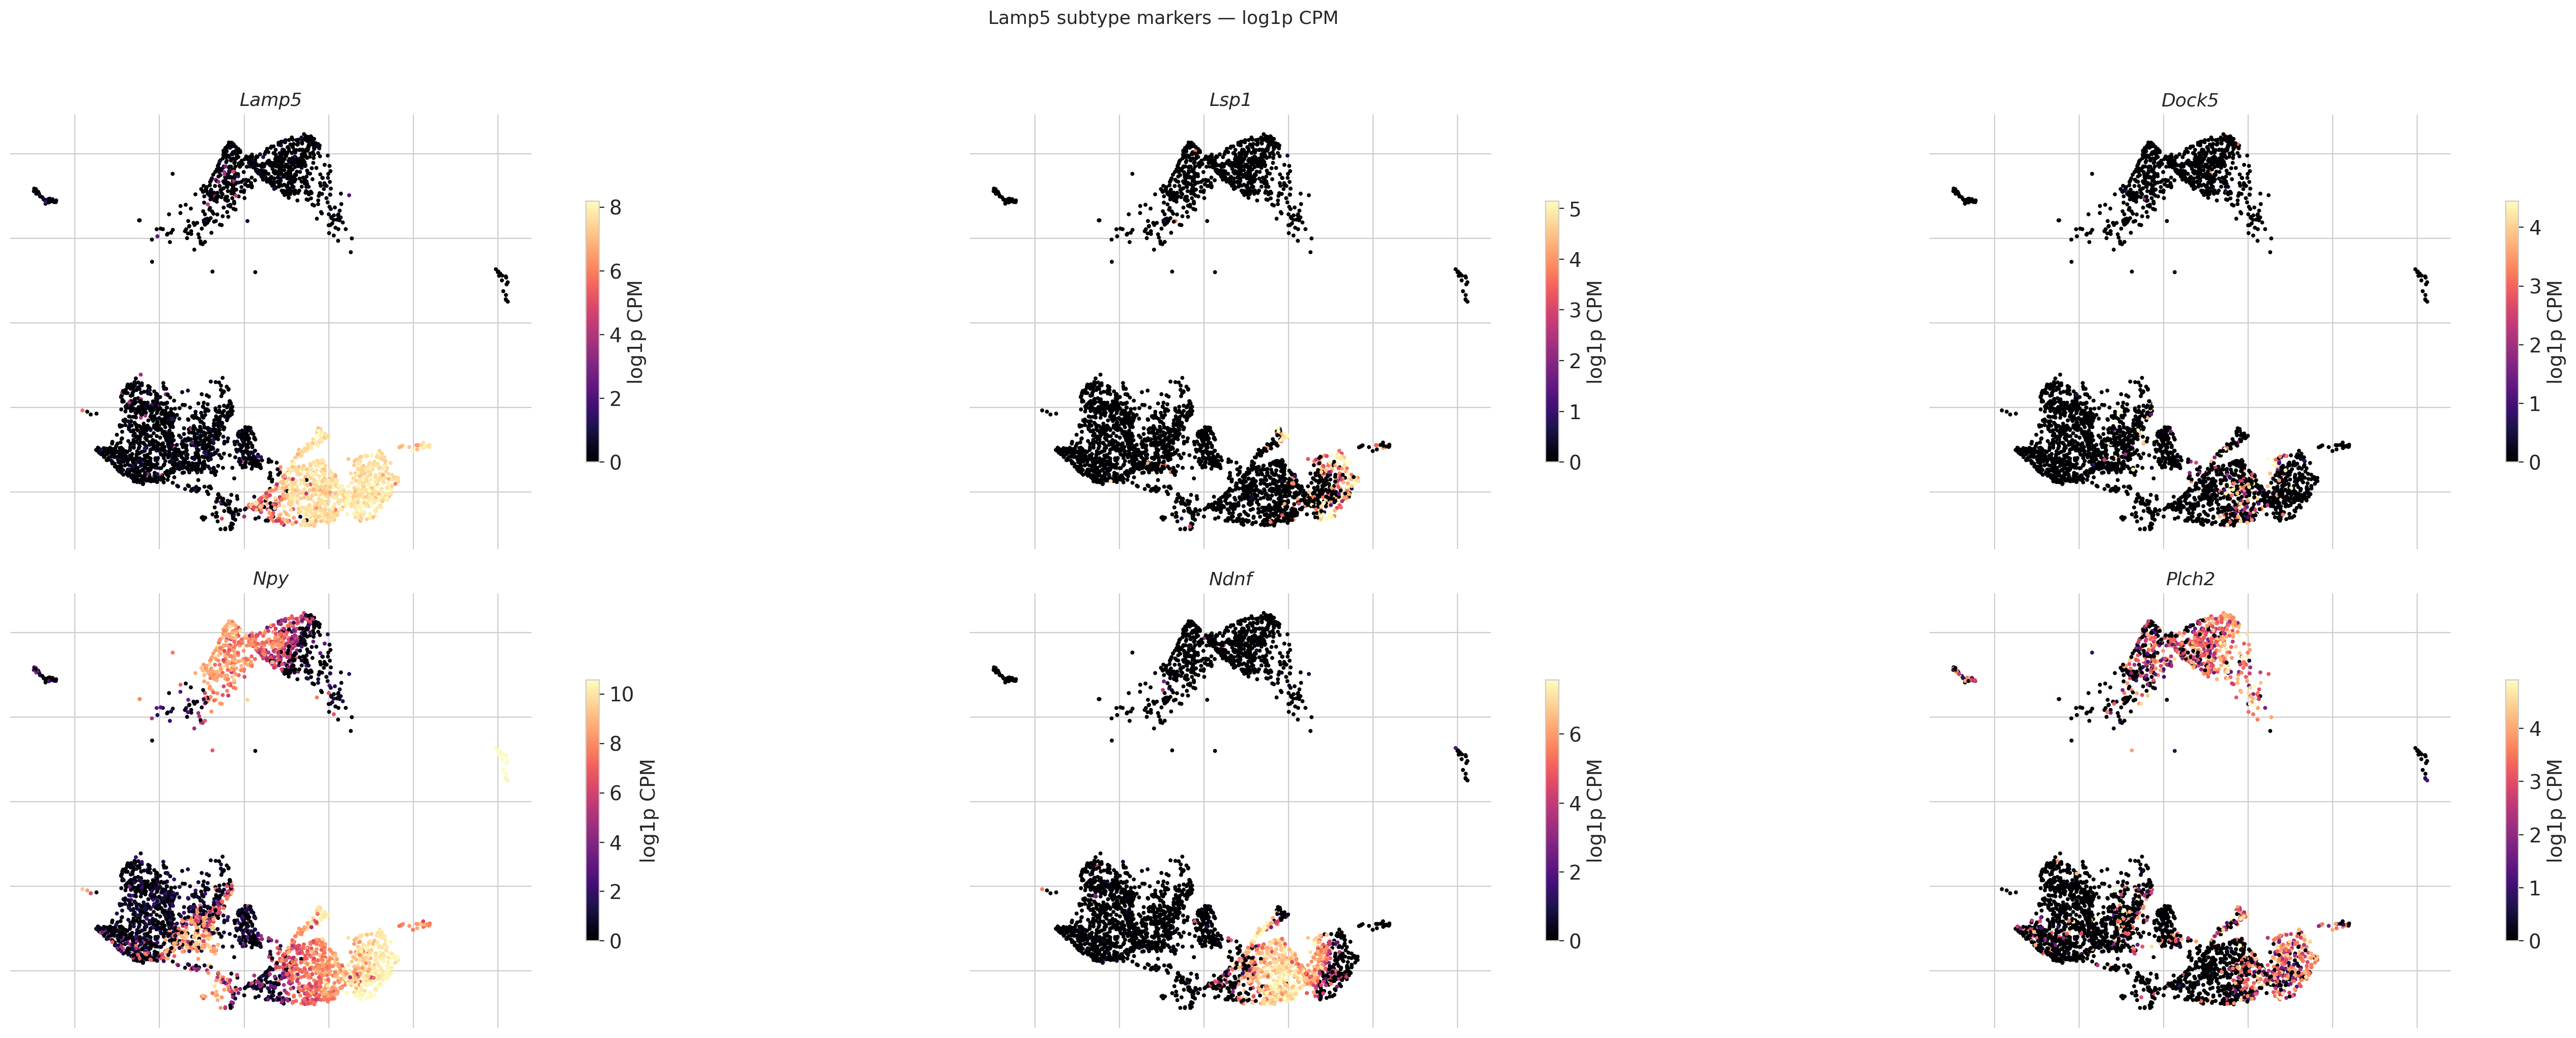

In [35]:
## Lamp5 subtype marker expression on UMAP

LAMP5_MARKERS = ['Lamp5', 'Lsp1', 'Dock5', 'Npy', 'Ndnf','Plch2']

# Fetch log1p(CPM) for each marker gene
gene_expr = {}
for g in LAMP5_MARKERS:
    entrez = sym_to_entrez.get(g)
    if entrez is None:
        print(f'Warning: {g} not found in Tasic gene set')
        continue
    col  = adata_l23_inh.var_names.get_loc(entrez)
    raw  = adata_l23_inh.layers['counts'][:, col]
    gene_expr[g] = np.log1p(raw / cell_total.squeeze() * 1e6)

# UMAP coordinates (all cells)
umap_all = adata_l23_inh.obsm['X_umap']

rng = np.random.default_rng(42)
idx = rng.permutation(len(umap_all))

fig, axes = plt.subplots(2, int(len(LAMP5_MARKERS)/2), figsize=(5 * len(LAMP5_MARKERS), 10))

for ax, g in zip(axes.ravel(), LAMP5_MARKERS):
    expr = gene_expr[g][idx]
    sc = ax.scatter(
        umap_all[idx, 0], umap_all[idx, 1],
        c=expr, cmap='magma', s=8, linewidths=0,
        vmin=0, vmax=np.percentile(expr, 99),
        rasterized=True,
    )
    ax.set_title(g, fontsize=13, style='italic')
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.colorbar(sc, ax=ax, shrink=0.6, label='log1p CPM')

fig.suptitle('Lamp5 subtype markers — log1p CPM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [36]:
## Cache Tasic MET-type centroids as high-resolution reference
#
# For each MET type, take the median log1p(CPM) across all assigned Tasic cells
# using the full transcriptome (all genes, not just the shared subset).
# Rows are ordered by subclass then MET number; columns are gene symbols.

import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path

met_labels_arr = adata_l23_inh.obs['met_type_pred_markers'].values
id_to_sym      = adata_l23_inh.var['gene_symbol']   # entrez_id → symbol

# Determine MET type order
assigned_mets = [
    m for m in sorted(
        set(met_labels_arr),
        key=lambda x: (
            SUBCLASS_ORDER_MET.index(x.split('-')[0]) if x.split('-')[0] in SUBCLASS_ORDER_MET else 99,
            int(x.split('-MET-')[1]) if '-MET-' in x else 0,
        )
    )
    if m != 'Unknown'
]

# Compute median log1p(CPM) per MET type without materialising the full matrix
centroids = {}
for met in assigned_mets:
    mask    = met_labels_arr == met
    X_sub   = adata_l23_inh.layers['counts'][mask]          # (n, n_genes)
    tot_sub = cell_total[mask]                               # (n, 1)
    X_log   = np.log1p(X_sub / tot_sub * 1e6)
    centroids[met] = np.median(X_log, axis=0)
    print(f'  {met:<20s}: {mask.sum()} cells')

tasic_met_ref = pd.DataFrame(
    centroids,
    index=id_to_sym.values,
).T
tasic_met_ref.index.name = 'MET-type'

print(f'\ntasic_met_ref shape: {tasic_met_ref.shape}  (MET types x genes)')

# Save via pyarrow directly (avoids pandas version check on pyarrow 10.0.0)
cache_path = Path(DATA_DIR) / 'cache' / 'tasic_met_centroids.parquet'
cache_path.parent.mkdir(exist_ok=True)
pq.write_table(pa.Table.from_pandas(tasic_met_ref), str(cache_path))
print(f'Saved -> {cache_path}')

  Pvalb-MET-4         : 471 cells
  Pvalb-MET-5         : 42 cells
  Sst-MET-1           : 17 cells
  Sst-MET-2           : 160 cells
  Sst-MET-3           : 99 cells
  Sst-MET-8           : 39 cells
  Vip-MET-1           : 412 cells
  Vip-MET-2           : 448 cells
  Vip-MET-4           : 50 cells
  Vip-MET-5           : 417 cells
  Lamp5-MET-1         : 981 cells
  Sncg-MET-1          : 66 cells

tasic_met_ref shape: (12, 45768)  (MET types x genes)
Saved -> /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/cache/tasic_met_centroids.parquet


In [37]:
## Cache per-cell MET-type assignments for all Tasic cells

from pathlib import Path

cell_labels = adata_l23_inh.obs[['subclass', 'cluster', 'met_type_pred_markers']].copy()
cell_labels.index.name = 'sample_name'

cache_path = Path(DATA_DIR) / 'cache' / 'tasic_met_assignments.csv'
cell_labels.to_csv(cache_path)
print(f'Saved {len(cell_labels)} cells -> {cache_path}')
print(cell_labels['met_type_pred_markers'].value_counts().head(15))

Saved 3202 cells -> /mnt/nasquatch/data/RNAseq/allenV1_SMART-seq/cache/tasic_met_assignments.csv
met_type_pred_markers
Lamp5-MET-1    981
Pvalb-MET-4    471
Vip-MET-2      448
Vip-MET-5      417
Vip-MET-1      412
Sst-MET-2      160
Sst-MET-3       99
Sncg-MET-1      66
Vip-MET-4       50
Pvalb-MET-5     42
Sst-MET-8       39
Sst-MET-1       17
Name: count, dtype: int64


### thinking about the specific questions we want to ask w/ this gene panel: 

- Continuous lamp5 variation 
- Pvalb chandelier cell differentiation
- For Sncg, do we need Sncg or are we good w/ VIP+/CCK+/PV-
- What is minimal set of differentiators for SST MET1-3,8
- What is minimal set of differentiators for VIP MET1,2,4,5